In [1]:
from matplotlib import pyplot as plt
from jax import numpy as jnp
# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0


In [5]:
def params(mean, std):
    'takes arithmetic params and returns classical params'
    mu = jnp.log(mean)-0.5*jnp.log((std/mean)**2+1)
    sigma = jnp.sqrt(jnp.log((std/mean)**2+1))
    return mu, sigma

def lognorm(x, mu, sigma):
    return 1/(x*sigma*jnp.sqrt(2*jnp.pi))*jnp.exp(-0.5*((jnp.log(x)-mu)/sigma)**2)

def gm_params(mu, sigma):
    'takes classical params and returns geometric params'
    mu_ = jnp.exp(mu)
    sigma_ = jnp.exp(sigma)
    return mu_, sigma_

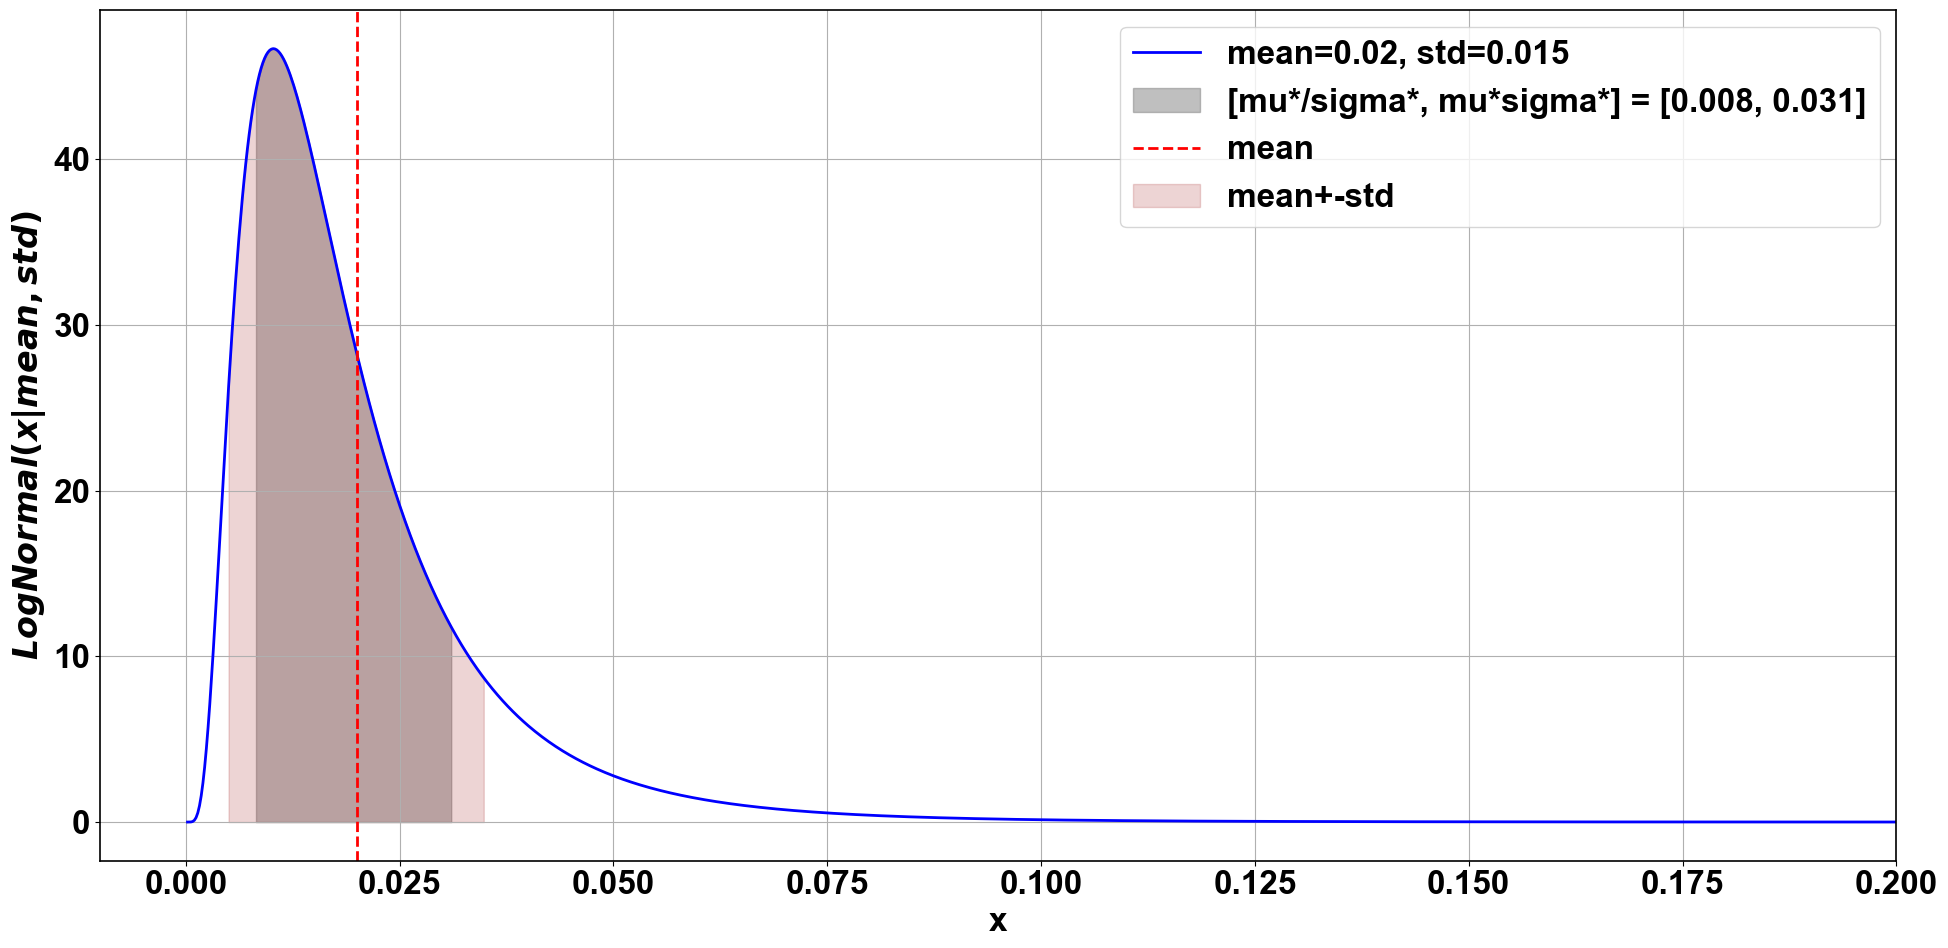

In [13]:
mean = 0.02
std = 0.015
fig, ax = plt.subplots(figsize=(20,10))
x = jnp.linspace(0, 0.2, 1000)
y = lognorm(x, *params(mean, std))
ax.set_xlabel('x')
ax.set_xlim(-0.01, 0.2)
ax.set_ylabel('$LogNormal(x|mean, std)$')
ax.plot(x, y, label=f'mean={mean}, std={std}', color='blue')
mu_, sigma_ = gm_params(*params(mean, std))
ax.fill_between(x, y, where=(x >= mu_/sigma_) & (x <= mu_*sigma_), color='gray', alpha=0.5, label=f'[mu*/sigma*, mu*sigma*] = [{mu_/sigma_:.3f}, {mu_*sigma_:.3f}]')
ax.axvline(mean, color='red', linestyle='--', label='mean')
ax.fill_between(x, y, where=(x >= mean-std) & (x <= mean+std), color='brown', alpha=0.2, label='mean+-std')
ax.grid()
ax.legend()
fig.tight_layout()